In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Cleaning Dataset

In [2]:
dfOld = pd.read_stata("Data/migrationResponses.dta")
dfOld.columns

Index(['zila', 'upza', 'year', 'xriverdensity_kmpersqkm', 'xlflood',
       'xslflood', 'ltavgannp', 'xlannp', 'xltot_precip_trmm'],
      dtype='str')

In [3]:
numeric_cols = [
    'xriverdensity_kmpersqkm',
    'xlflood',
    'xslflood',
    'ltavgannp',
    'xlannp',
    'xltot_precip_trmm'
]

for col in numeric_cols:
    dfOld[col] = pd.to_numeric(dfOld[col], errors='coerce')

dfOld['zila'] = dfOld['zila'].astype(str).str.strip()
dfOld['upza'] = dfOld['upza'].astype(str).str.strip()
dfOld['year'] = pd.to_numeric(dfOld['year'], errors='coerce').astype('Int64')

dfOld = dfOld.rename(columns={
    'zila': 'district',
    'upza': 'subdistrict',
    'xriverdensity_kmpersqkm': 'river_density',
    'xlflood': 'large_flood',
    'xslflood': 'small_flood',
    'ltavgannp': 'long_term_avg_precip',
    'xlannp': 'annual_precip',
    'xltot_precip_trmm': 'total_precip'
})

df = dfOld.copy()

### Initial Analysis

In [4]:
yearly = df.groupby('year')[[
    'annual_precip',
    'total_precip',
    'large_flood',
    'small_flood'
]].mean().reset_index()

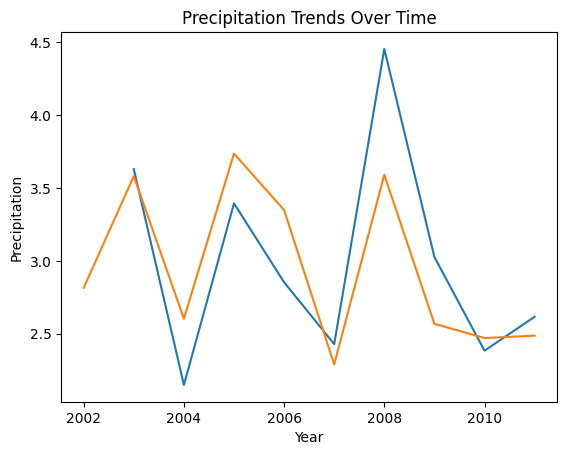

In [5]:
#precipitation over time
plt.figure()
plt.plot(yearly['year'], yearly['annual_precip'])
plt.plot(yearly['year'], yearly['total_precip'])
plt.xlabel("Year")
plt.ylabel("Precipitation")
plt.title("Precipitation Trends Over Time")
plt.show()

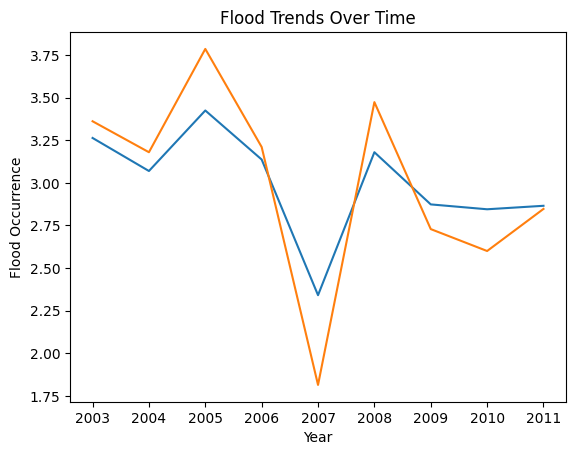

In [6]:
#flood over time
plt.figure()
plt.plot(yearly['year'], yearly['large_flood'])
plt.plot(yearly['year'], yearly['small_flood'])
plt.xlabel("Year")
plt.ylabel("Flood Occurrence")
plt.title("Flood Trends Over Time")
plt.show()